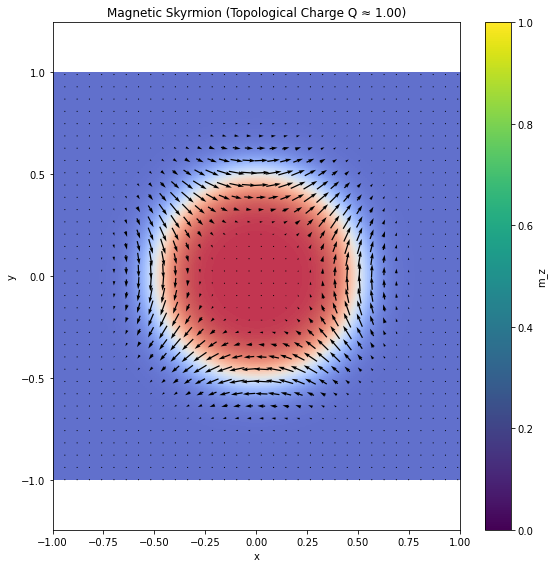

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Grid parameters
L = 200  # number of points per axis
x = np.linspace(-1, 1, L)
y = np.linspace(-1, 1, L)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# Skyrmion profile: theta(r) changes from pi to 0
R0 = 0.5   # core size
lambda_ = 10  # controls sharpness
theta = 2 * np.arctan(np.exp(lambda_ * (R - R0)))  # polar angle

# Magnetization components (Bloch-type skyrmion)
m_x = np.sin(theta) * np.cos(phi)
m_y = np.sin(theta) * np.sin(phi)
m_z = np.cos(theta)

# Compute partial derivatives
dx = x[1] - x[0]
dy = y[1] - y[0]
dmx_dx, dmx_dy = np.gradient(m_x, dx, dy, edge_order=2)
dmy_dx, dmy_dy = np.gradient(m_y, dx, dy, edge_order=2)
dmz_dx, dmz_dy = np.gradient(m_z, dx, dy, edge_order=2)

# Calculate skyrmion density
cross_x = dmy_dx * dmz_dy - dmz_dx * dmy_dy
cross_y = dmz_dx * dmx_dy - dmx_dx * dmz_dy
cross_z = dmx_dx * dmy_dy - dmy_dx * dmx_dy

density = m_x * cross_x + m_y * cross_y + m_z * cross_z
Q = (1 / (4 * np.pi)) * np.sum(density) * dx * dy

# Subsample for vector field clarity
step = 6
Xq = X[::step, ::step]
Yq = Y[::step, ::step]
U = m_x[::step, ::step]
V = m_y[::step, ::step]
C = m_z  # color background

# Plotting
plt.figure(figsize=(8, 8))
plt.imshow(C, extent=[-1, 1, -1, 1], origin='lower', cmap='coolwarm', alpha=0.8)
plt.quiver(Xq, Yq, U, V, scale=25, color='k', pivot='middle', width=0.003)
plt.title(f'Magnetic Skyrmion (Topological Charge Q ≈ {Q:.2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='m_z')
plt.axis('equal')
plt.tight_layout()
plt.show()
